<div class="alert alert-block alert-info">
¡Hola! Adrian ¿Cómo vas?

Mi nombre es Santiago. Un gusto conocerte, seré tu revisor en este proyecto.

Cuando encuentre un error por primera vez, simplemente lo señalaré para que lo detectes y corrijas por tu cuenta. Si en la siguiente iteración no lograste resolverlo, te daré una pista más precisa con ejemplos. ¡También estoy disponible para cualquier duda que tengas!

Encontrarás mis comentarios a continuación: por favor, no los muevas, modifiques ni elimines.
</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor.</b>

Éxito. Todo se ha hecho de forma correcta.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor.</b>

Observación. Algunas recomendaciones o mejoras menores.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor.</b>

Necesita arreglos. El trabajo no puede ser aceptado con comentarios rojos.
</div>

<div class="alert alert-block alert-info">
Puedes responder utilizando este formato:

Respuesta del estudiante.
</div>

<div class="alert alert-block alert-danger">
<b>Review General. (Iteración 1)</b> <a class="tocSkip"></a>

Antes de entrar en el detalle, quiero compartirte mis impresiones generales.

Se nota un buen trabajo analítico en varios puntos: identificaste correctamente los sentinels con sus cantidades exactas (55 en `age`, 96 en `city`), usaste `np.select()` para la segmentación (la forma más eficiente que pedía la rúbrica), tus histogramas tienen `hue="plan"`, el IQR calcula correctamente ambos límites, y el insight ejecutivo tiene cifras concretas y recomendaciones de negocio razonables. ¡Buen trabajo en esos puntos!

Hay dos puntos que necesitan corrección antes de aprobar:

- **Diagnóstico de nulos (celda 16):** para `duration` y `length` propones imputar, pero como confirmarás en el Paso 3.2, estos nulos son estructurales (MAR) y deben conservarse como nulos, no imputarse.
- **Diagnóstico de nulos (celda 16):** para `date` propones "ignorar", que es ambiguo. La acción correcta es conservarlos como `NaT`.

También te dejo algunas observaciones menores. ¡Estás muy cerca de aprobar!

Saludos.
</div>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [25]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡Perfecto! Importaste `pandas`, `seaborn`, `matplotlib` y `numpy` desde el inicio. ✅
</div>

In [26]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [27]:
plans.head(5) #mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [28]:
users.head(5) # mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [29]:
usage.head(5) # mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [30]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [31]:
plans.info() # inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [32]:
users.info() # inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [33]:
usage.info() # inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Bien verificando dimensiones con `.shape` e inspeccionando los tres datasets con `.info()`. ✅
</div>

---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [34]:
users.isna().sum() # cantidad de nulos para users
print( "Cantidad de valores nulos:",users.isna().sum())
print( "Proporción de valores nulos:",(users.isna().mean()*100).round(2))

Cantidad de valores nulos: user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
Proporción de valores nulos: user_id        0.00
first_name     0.00
last_name      0.00
age            0.00
city          11.72
reg_date       0.00
plan           0.00
churn_date    88.35
dtype: float64


In [35]:
(users['city'] == '?').sum()

96

In [36]:
usage.isna().sum() # cantidad de nulos para usage
print( "Cantidad de valores nulos:",usage.isna().sum())
print( "Proporción de valores nulos:",usage.isna().mean())

Cantidad de valores nulos: id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
Proporción de valores nulos: id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Bien calculando nulos con `isna().sum()` y `isna().mean()`. ✅

Un tip de presentación: usar `.mul(100).round(2)` convierte la proporción a porcentaje directamente con dos decimales, lo que hace el output más legible:

```python
print((users.isna().mean() * 100).round(2))
```
</div>


✍️ **Comentario**: El el dataframe "users" hay 2 items que tienen valores nulos ('city' y 'churn date'). Para el segundo dataframe "usage" hay 3 items que tienen valores nulos ('date', 'duration','length') 

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- En dataframe 'users' en la columna 'city' hay un total de 469 valores nulos + 96 sentinels lo que representa 11,72% del total. En este caso se puede dejar con valores nulos y reemplazar los sentinels por valores nulos.
- En dataframe 'users'en la columna 'churn_date' hay un total 3534 datos nulos lo que representa 88,35% se van a ignorar en el analisis.
- En el dataframe 'usage' de la columna 'date' hay 50 valores nulos lo que representa 0.125% del total,por lo tanto se conservar como 'NaT', ya que el evento sigue siendo valido, solo se desconoce la fecha.
- En el dataframe 'usage' de la columna 'duration' hay 22076 valores nulos lo que representa 55.19% del total, por lo tanto no se deben imputar, sino conservar como nulos (Missing at random-MAR)
 - En el dataframe 'usage' de la columna 'length' hay 17896 valores nulos lo que representa 44.74% del total, por lo tanto no se deben imputar, sino conservar como nulos (Missing at random-MAR).


<div class="alert alert-block alert-danger">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

El diagnóstico identifica correctamente las columnas y sus proporciones. ✅

Hay dos acciones que necesitan ajustarse:

**1. `duration` y `length` — "investigar e imputar":** Como confirmarás en el Paso 3.2, los nulos en estas columnas son **MAR (Missing At Random)** — dependen estructuralmente del tipo de evento en `type`. La duración no aplica a mensajes y la longitud no aplica a llamadas, por lo que imputar introduciría información inventada. La acción correcta es **conservarlos como nulos** y documentarlo.

**2. `date` — "ignorar":** Los 50 nulos en `date` son registros cuya fecha no pudo convertirse. "Ignorar" es ambiguo — la acción correcta es **conservarlos como `NaT`** (que es lo que ya ocurre por defecto con `errors="coerce"`). El evento de uso sigue siendo válido, solo se desconoce la fecha.
</div>

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [37]:
num_cols=['user_id','age']
users[num_cols].describe()   # explorar columnas numéricas de users

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


In [38]:
(users['age']==-999).sum() #cantidad de sentinels en la columna 'age'

55

- La columna `user_id` no se observa sentinels, por ende no recomiendo  ningun cambio.
- La columna `age` hay 2 items que llaman la atencion: desviacion estandard (std) que es de 123 y este tiene que ver con el segundo item min -999 lo que representa un sentinels que tiene que ser corregido y reemplazado con la mediana. Hay 55 sentinels en la columna 'age' segun el codigo de mas arriba.

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡Buen análisis numérico! Detectaste el sentinel `-999` en `age` y verificaste con código que son **55 registros** — cifra exacta y correcta. ✅
</div>

In [39]:
num_cols=['user_id','id']
usage[num_cols].describe() # explorar columnas numéricas de usage

,user_id,id
count,40000.000000,40000.00000
mean,12002.405975,20000.50000
std,1157.279564,11547.14972
min,10000.000000,1.00000
25%,10996.000000,10000.75000
50%,12013.000000,20000.50000
75%,13005.000000,30000.25000
max,13999.000000,40000.00000


- Las columnas `id` y `user_id` no presentan sentinels.


In [40]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users['city'].value_counts(dropna=False)


Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

- La columna `city` hay 96 sentinels "?" que se deben corregir
- La columna `plan` no se observa sentinels para mencionar

<div class="alert alert-block alert-warning">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Identificaste correctamente el sentinel `"?"` en `city` con su cantidad exacta (96). ✅

Tip: `.describe()` en columnas categóricas no garantiza mostrar todos los valores problemáticos. Para este objetivo es más seguro usar `value_counts(dropna=False)`:

```python
users["city"].value_counts(dropna=False)
```
</div>

In [41]:
# explorar columna categórica de usage
usage['type'].describe() 

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` no se observa ningun sentinels.


---
✍️ **Comentario**: Se han encontrado valores nulos y sentinels segun el detalle de mas abajo. 

**Valores inválidos o sentinels**  
- En el data frame 'users' en columna 'city'  he encontrado  96 sentinels "?" y en la columna 'age' he encontrado 55 sentinels "-999"
- en el data frame 'usage' no he visualizado ningun sentinels.
-  Para la columna 'city' se utilizara reemplazo de estos sentinels "?" con "pd.NA" y para la columna 'age' se remplazara los sentinels "-999" con la mediana.

<div class="alert alert-block alert-warning">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Diagnóstico correcto en esencia: identificas los 55 sentinels en `age` y los 96 en `city`. ✅

Un matiz: el diagnóstico menciona reemplazar el `"?"` con `"NaN"` (el string o el float de numpy), pero la instrucción pide `pd.NA` (el valor nulo nativo de pandas modernos). Tu código en la celda 38 sí usa `pd.NA` correctamente — solo actualiza el texto del diagnóstico.
</div>

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [42]:
# Convertir a fecha la columna `reg_date` de users
users["reg_date"] =pd.to_datetime(users["reg_date"],errors="coerce") 

<div class="alert alert-block alert-warning">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

La conversión funciona correctamente en este dataset. ✅

Te recomiendo agregar `errors="coerce"` para hacer el código robusto ante valores que no puedan convertirse:

```python
users["reg_date"] = pd.to_datetime(users["reg_date"], errors="coerce")
```
</div>

In [43]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'])

In [44]:

# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()



2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, se observan fechas futuras (año 2026) lo que es erroneo. Por el intervalo 2022-2024 no se observa diferencias grandes.

In [45]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En columna `date`, en dataframe 'usage' se observa que toda las fechas son del años 2024.


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Bien identificando los 40 registros del 2026 y confirmando que `date` solo tiene 2024. ✅
</div>

✍️ **Comentario**: 40 registros del año 2026 se han observado en 'users' 

**Fechas fuera de rango**  
- En el data frame 'users' en la columna 'reg_date' hay 40 registros de un año en futuro (2026)
- Se marcara como nulas las fechas fuera del rango (hasta 2024)

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡Diagnóstico de fechas correcto y preciso! Identificas los 40 registros del 2026 como fuera de rango y propones marcarlos como nulos (no eliminarlos). ✅
</div>

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [46]:


# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999,age_mediana)

# Verificar cambios
users['age'].describe()



count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

El reemplazo del sentinel `-999` con la mediana y la verificación son correctos. ✅
</div>

In [47]:
# Reemplazar ? por NA en city
users['city']=users['city'].replace('?',pd.NA)

# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

Correcto. Reemplazaste `"?"` por `pd.NA`. ✅
</div>

In [48]:

# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year>2024,'reg_date']=pd.NaT

# Verificar cambios
users['reg_date'].describe()


count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡Perfecto! `.loc[dt.year > 2024] = pd.NaT` es la forma correcta. ✅
</div>

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.
  - Los nulos de 'duration' y 'length' son relacionados con otra variable que es 'type', por ende se trata de MAR (missing at random) y se dejan como nulos.

In [49]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isnull().groupby(usage['type']).mean()

type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [50]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isnull().groupby(usage['type']).mean()

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
Estructuralmente es normal que en 'duration'los nulos aparezca cuando type='text', ya que un texto no se puede medir en duracion.
Estructuralmente es normal que en 'length'los nulos aparezca cuando type='call', ya que una llamada no se puede medir en longitud.

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡MAR correctamente identificado! La explicación de por qué `duration` no aplica a textos y `length` no aplica a llamadas es exactamente la justificación correcta. ✅

Recuerda actualizar el diagnóstico de la celda 16 para que sea consistente con esta conclusión (conservar los nulos, no imputar).
</div>

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [51]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg(cant_mensajes=("is_text","sum"),cant_llamadas=("is_call","sum"),cantidad_minutos_llamadas=('duration',"sum")).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cantidad_minutos_llamadas
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [52]:
# Renombrar columnas
usage_agg =usage_agg.rename(columns ={"cantidad_mensajes":"cant_mensajes","cantidad_llamadas":"cant_llamadas", "cantidad_minutos_llamadas":"cant_minutos_llamada"})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [53]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = user_profile=pd.merge(users,usage_agg,on=['user_id'],how='inner')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01


<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡El resultado final de la agrupación y el merge es correcto! Verifiqué el output real: las columnas `cant_mensajes`, `cant_llamadas` y `cant_minutos_llamada` existen con los valores esperados. ✅

Dos tips de limpieza:

1. **Cell 46 (rename):** las entradas `"cantidad_mensajes"` y `"cantidad_llamadas"` en el rename no existen en `usage_agg` (ya se nombraron directamente en el `.agg()` como `cant_mensajes` y `cant_llamadas`), por lo que no tienen efecto. Solo la entrada `"cantidad_minutos_llamadas"→"cant_minutos_llamada"` funciona. Puedes simplificar el código usando el nombre correcto directamente en el `.agg()`:

```python
cant_minutos_llamada=("duration", "sum")
```

2. **Cell 47 (merge):** la instrucción pedía `how="left"` para conservar todos los usuarios incluso sin actividad. Usaste `how="inner"` por defecto.
</div>

### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [54]:
# Resumen estadístico de las columnas numéricas
col_num =['age','cant_mensajes','cant_llamadas','cant_minutos_llamada']
user_profile[col_num].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000,3999.000000
mean,48.124531,5.524381,4.478120,23.317054
std,17.692032,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [62]:




# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True).mul(100).round(2)





Basico     64.87
Premium    35.13
Name: plan, dtype: float64

<div class="alert alert-block alert-warning">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

El resumen estadístico incluye las cuatro columnas relevantes de comportamiento. ✅

Dos tips:

1. `user_id` como identificador no aporta interpretación analítica en el `.describe()`. Puedes excluirlo:

```python
user_profile[["age","cant_mensajes","cant_llamadas","cant_minutos_llamada"]].describe()
```

2. En la celda 50, la primera línea `value_counts()` (sin `normalize=True`) muestra conteos y Jupyter solo muestra el resultado de la última línea, así que la primera es redundante. Puedes eliminarla y agregar `.mul(100).round(2)` para ver directamente los porcentajes.
</div>

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

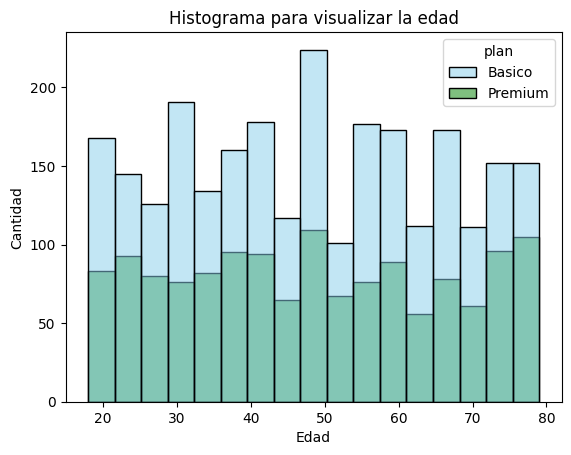

In [63]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile,x='age',hue='plan',palette=['skyblue', 'green'])
plt.title ("Histograma para visualizar la edad") 

plt.xlabel("Edad")
plt.ylabel("Cantidad")

plt.show()

💡Insights: 
- Distribución observada es simetrica, con un peak en la categoria 47-50 años (sobre 200 planes)
- Dentro del plan Premium se puede observar un porcentaje mayor a 50% en las mayorias de las categorias de edades, excepto la categoria 28-33 años.
- Se puede observar que los usuarios con plan Basico tienen la tendencia de utilizar mas mensajeria que llamadas en la categoria de edad comprendidas entre 18 y 47 años lo que tiene sentido ya que esta categoria de usuarios les gusta utilizar este tipo de tecnologia (mensajeria tipica o chats de conversacion)

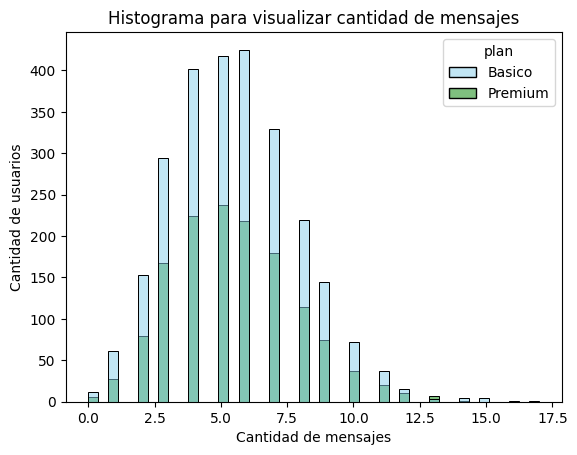

In [64]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile,x='cant_mensajes',hue='plan',palette=['skyblue', 'green'])
plt.title ("Histograma para visualizar cantidad de mensajes") 

plt.xlabel("Cantidad de mensajes")
plt.ylabel("Cantidad de usuarios")

plt.show()

💡Insights: 
- En esta historigrama se puede ver que hay una distribucion levemente asimentrica media > mediana o sea se trata de un distribucion con sesgo a la derecha.
- Visualmente se puede notar que hay una pequña cantidad de usuarios que tiene una cantidad grande de mensajes sobre la media (15 -17.5 mensajes).
- La proporcion entre mensajes vs llamadas por bloque de cantidades de mensajes se mantiene equilibrada (50%-50%) excepto en la extremidad derecha como he mencioando mas arriba.

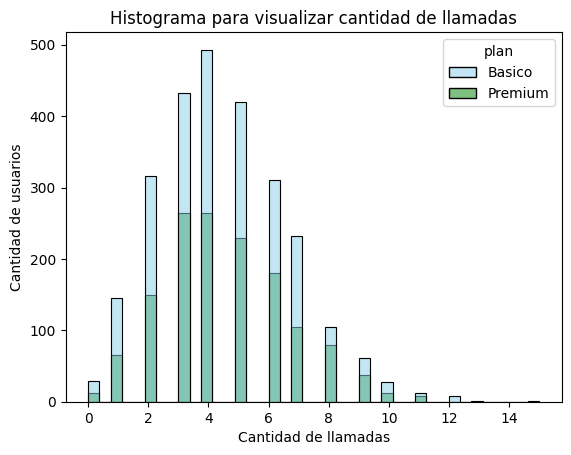

In [65]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile,x='cant_llamadas',hue='plan',palette=['skyblue', 'green'])
plt.title ("Histograma para visualizar cantidad de llamadas") 

plt.xlabel("Cantidad de llamadas")
plt.ylabel("Cantidad de usuarios")

plt.show()

💡Insights: 
- Distribución levemente asimentrica con sesgo a la derecha con muy pequeña variacion entre media y mediana.
- Visualmente se puede notar que la distribucion de las llamadas por usuarios y tipo de plan es bastante equilibrada (50% mensajes -50% llamadas) excepto por la cantidad de usurios que tiene una cantidad de mensajes + llamadas sobre la media.

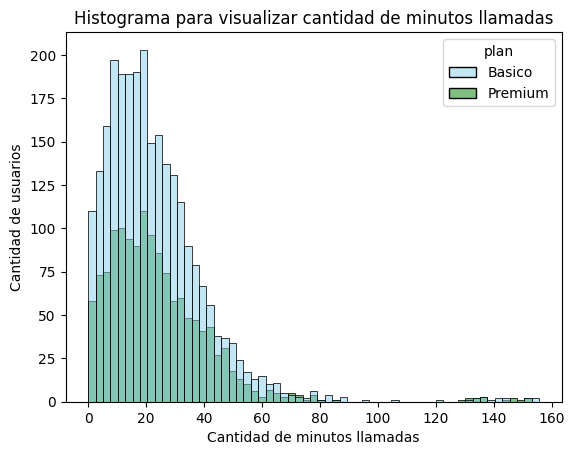

In [66]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile,x='cant_minutos_llamada',hue='plan',palette=['skyblue', 'green'])
plt.title ("Histograma para visualizar cantidad de minutos llamadas") 

plt.xlabel("Cantidad de minutos llamadas")
plt.ylabel("Cantidad de usuarios")

plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡Los cuatro histogramas usan `hue="plan"`, tienen títulos y etiquetas! Los insights son descriptivos y bien contextualizados. ✅
</div>

💡Insights: 
- La distribucion de esta historigrama es asimetrica, ya que se pueden observar la cola de cantidad de  minutos llamadas hacia derecha por ende tiene sesgo a la derecha.
- Se nota una cantidad de usuarios que tienen una cantidad de minutos llamadas muy sobre la media, y este se puede interpretar viendo que la desviacion es de 18.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

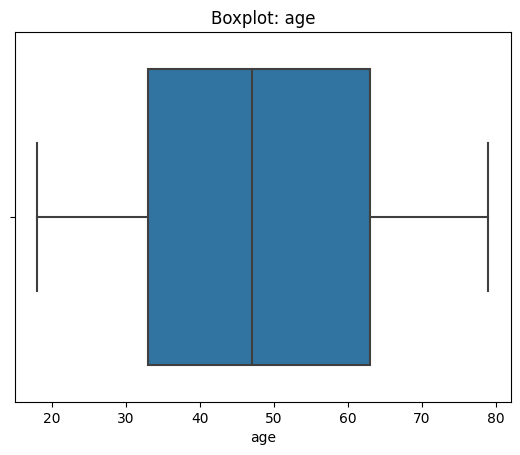

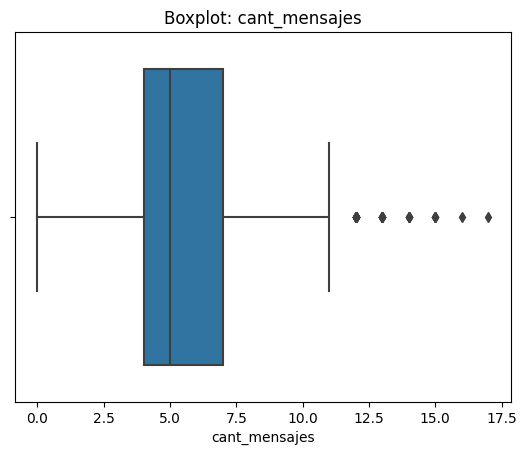

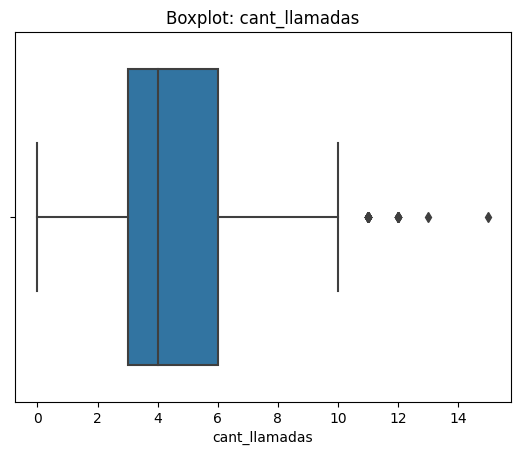

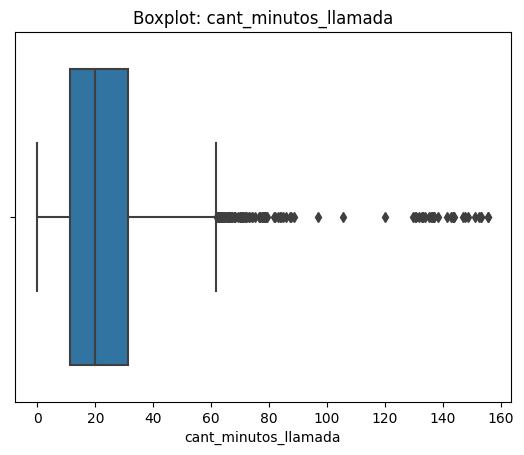

In [67]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile,x=col)
    
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: no presenta outliers
- cant_mensajes: presenta outliers
- cant_llamadas: presenta outliers
- cant_minutos_llamada:presenta outliers

In [68]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes','cant_llamadas','cant_minutos_llamada']

for col_lim in columnas_limites:
    Q1 = user_profile[col_lim].quantile(0.25)
    print('Primer cuartil: ', Q1)
    Q3 = user_profile[col_lim].quantile(0.75)
    print('Tercer cuartil: ', Q3)
    IQR = Q3 - Q1
    print('IQR: ', IQR)
    lower = Q1 - 1.5 * IQR
    print('Límite inferior: ', lower)
    upper = Q3 + 1.5 * IQR
    print('Límite superior: ', upper)



Primer cuartil:  4.0
Tercer cuartil:  7.0
IQR:  3.0
Límite inferior:  -0.5
Límite superior:  11.5
Primer cuartil:  3.0
Tercer cuartil:  6.0
IQR:  3.0
Límite inferior:  -1.5
Límite superior:  10.5
Primer cuartil:  11.12
Tercer cuartil:  31.415
IQR:  20.295
Límite inferior:  -19.322500000000005
Límite superior:  61.8575


In [69]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[col_lim].describe()

count    3999.000000
mean       23.317054
std        18.168095
min         0.000000
25%        11.120000
50%        19.780000
75%        31.415000
max       155.690000
Name: cant_minutos_llamada, dtype: float64

💡Insights: 
- cant_mensajes: límite superior: 11.5, máximo real: 17 se mantienen los outliers ya que se trata de comportamento de usuario
- cant_llamadas: límite superior: 10.5, máximo real: 15 se mantienen los outliers ya que se trata de comportamento de usuario
- cant_minutos_llamada: 61.86, máximo real: 155.69 se mantienen los outliers ya que se trata de comportamento de usuario

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡El IQR calcula correctamente el límite inferior y el superior para las tres variables! Los insights están completos con los valores exactos y la justificación de mantener los outliers. ✅

Tip: en la celda 64, `user_profile[col_lim].describe()` usa `col_lim`, que queda con el valor de la última iteración del bucle anterior (`"cant_minutos_llamada"`). Para ver el describe de las tres columnas juntas:

```python
user_profile[columnas_limites].describe().loc[["75%","max"]]
```
</div>

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [70]:
# Crear columna grupo_uso
user_profile['grupo_uso']= np.select([(user_profile['cant_llamadas'] <5 )& (user_profile['cant_mensajes'] < 5),
                                      (user_profile['cant_llamadas'] <10 )& (user_profile['cant_mensajes'] < 10)],
                                      ['Bajo uso','Uso medio'],default='Alto uso')

In [71]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [72]:
# Crear columna grupo_edad
user_profile['grupo_edad']=np.select([(user_profile['age'] <30 ),
                                      (user_profile['age'] <60 )],
                                      ['Joven','Adulto'],
                                       default='Adulto Mayor')

In [73]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile,x="grupo_uso")
plt.xlabel("Tipo de uso")
plt.ylabel("Cantidad")
plt.title("Distribucion de usuarios por uso de planes")
plt.show()

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile,x="grupo_edad")
plt.xlabel("Edad")
plt.ylabel("Cantidad")
plt.title("Distribucion de usuarios por edad")
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡Excelente elección de `np.select()` para ambas segmentaciones! Es la forma vectorizada más eficiente y la que pedía la rúbrica. Los countplots tienen títulos y etiquetas. ✅

Tip opcional: agrega `order=["Bajo uso","Uso medio","Alto uso"]` y `order=["Joven","Adulto","Adulto Mayor"]` para garantizar el orden lógico de las barras.
</div>


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- En dataframe ‘users’ se han encontrado: En la columna ‘city’ una cantidad de 469 valores nulos (11,725% del total) y en columna ‘churn_date’ una cantidad de 3.534 valores nulos (88,35% del total) 
- En dataframe ‘usage’ se han encontrado: En la columna ‘date’ una cantidad de 50 valores nulos (0,125% del total) , en columna ‘duration’ una cantidad de 22.076 valores nulos (55,19% del total) y en columna ‘length’ una cantidad de 17.896 valores nulos (44,74% del total) 

🔍 **Segmentos por Edad**
- Segmentacion por edad establecida es: 'Joven' cuando age < 30 , 'Adulto' cuando age < 60, 'Adulto Mayor' para el resto de casos
- La distribucion que se puede ver en los graficos de la seccion anterior de este proyecto es de : 'Adulto' - 50%, 'Adulto Mayor' - 30% y 'Joven' -20%.


📊 **Segmentos por Nivel de Uso**
- Segmentacion por uso establecida es: 'Bajo uso' cuando llamadas < 5 y mensajes < 5, 'Uso medio' cuando llamadas < 10 y mensajes < 10, 'Alto uso' para el resto de casos.
- La distribucion que se puede ver en los graficos de la seccion anterior de este proyecto es de 'Medio Uso' - 75%, 'Bajo Uso' - 19% y 'Alto Uso' - 6%


➡️ Esto sugiere que los segmentos mas valiosos para ConectaTel son los del grupo 'Adulto' y de 'Uso Medio' ya que son los grupos con la  mayor actividad y uso de servicio.
En termino de outliers se ha encontrado en las columnas de 'cant_mesajes' , 'cant_llamadas' y 'cant_minutos_llamada' y mi recomendacion es de mantenerlos ya que no se trata de errores, y se trata de comportamiento de usuario, y el impacto en el negocio es muy bajo.



💡 **Recomendaciones**
- Despues la segmentacion de clientes realizadas por edad, se deberia utilizar una campañia estrategica de marketing para los jovenes para aumentar el uso de la telecomunicaciones, especialmentes llamadas, lo que podria impactar el negocio de manaera positiva por aumento de la cantidad de jovenes y de planes premium en vez de basico.
- Despues de la segmentacio de clientes por el uso, se deberia revisar si estos usuarios son del medio urbano o del medio rural. Para aumentar el uso en medio rural, la compañia deberia buscar mejorar la cobertura de telecomunicaciones en los lugares con bajo uso via inversiones en infraestructura especifica de telecomunicaciones (torres, antenas, etc.)
   

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

¡Buen insight ejecutivo! Tiene cifras exactas para los problemas de datos, segmentos cuantificados y recomendaciones de negocio concretas. ✅

La recomendación sobre mejorar infraestructura rural para aumentar el uso es una perspectiva estratégica interesante y poco frecuente. ✅
</div>

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `https://github.com/adriantanasa876-alt/everpeak-analysis`

<div class="alert alert-block alert-success">
<b>Comentario del revisor. (Iteración 1)</b> <a class="tocSkip"></a>

El link al repositorio está en una celda Markdown. ✅

Tip: el link está entre backticks (`` ` ``), lo que lo muestra como código en lugar de como hipervínculo. Para que sea clickeable usa formato Markdown:

```markdown
[Ver repositorio en GitHub](https://github.com/adriantanasa876-alt/everpeak-analysis)
```

También verifica que el repositorio sea **público** y tenga un `README.md`.
</div>